In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:38021")
client

<Client: 'tcp://127.0.0.1:38021' processes=10 threads=60, memory=113.67 GiB>

In [2]:
import xarray as xr
import numpy as np
import os.path as op
import tripyview as tpv
from xgcm.grid import Grid
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
ddir = "/work/uo0119/a270067/runtime/awicm3-v3.1/"
sdir = "/scratch/b/b383315/"
wdir = "/work/ba1254/b383315/fesom2/next/"

In [5]:
NXX = 48
ds1 = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/salt.fesom.2000.nc"
                              % NXX),
                     chunks={"nz1":1,"x":100000}
                    )
ds = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/w.fesom.2000.nc"
                             % NXX),
                     chunks={"nz":1,"x":100000}
                    )

dz = xr.DataArray(np.diff(ds.nz), dims=["nz1"],
                  coords={"nz1":ds1.nz1}
                 )

ds1, ds

(<xarray.Dataset> Size: 29GB
 Dimensions:  (time: 12, nz1: 47, x: 12952215)
 Coordinates:
   * time     (time) datetime64[ns] 96B 2000-01-31T23:57:00 ... 2000-12-31T23:...
   * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
 Dimensions without coordinates: x
 Data variables:
     salt     (time, nz1, x) float32 29GB dask.array<chunksize=(1, 1, 100000), meta=np.ndarray>
 Attributes: (12/21)
     CDI:                                 Climate Data Interface version 2.2.4...
     Conventions:                         CF-1.6
     FESOM_model:                         FESOM2
     FESOM_website:                       fesom.de
     FESOM_git_SHA:                       e23bc823
     FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
     ...                                  ...
     FESOM_evp_rheol_steps:               120
     FESOM_opt_visc:                      7
     FESOM_use_wsplit:                    -1
     FESOM_autorotate_back_to_geo: 

In [6]:
dt = 180. # 3 minutes

mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )

diag = xr.open_dataset(op.join(mesh_path, 'fesom.mesh.diag.nc'),
                       chunks={'n3':1,'elem_n':100000,
                               'nod_n':100000,'edg_n':100000}
                      )

diag

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp
 > augment lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_focus=0.shp
___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________


<xarray.Dataset> Size: 10GB
Dimensions:            (nz: 48, nz1: 47, elem: 25742475, nod2: 12952215, n3: 3,
                        n2: 2, N: 8, edg_n: 38695599, n4: 4)
Coordinates:
  * nz                 (nz) float64 384B 0.0 -5.0 -10.0 ... -6e+03 -6.25e+03
  * nz1                (nz1) float64 376B -2.5 -7.5 ... -5.825e+03 -6.125e+03
Dimensions without coordinates: elem, nod2, n3, n2, N, edg_n, n4
Data variables: (12/19)
    elem_area          (elem) float64 206MB dask.array<chunksize=(25742475,), meta=np.ndarray>
    nlevels_nod2D      (nod2) int32 52MB dask.array<chunksize=(12952215,), meta=np.ndarray>
    nlevels            (elem) int32 103MB dask.array<chunksize=(25742475,), meta=np.ndarray>
    nod_in_elem2D_num  (nod2) int32 52MB dask.array<chunksize=(12952215,), meta=np.ndarray>
    nod_part           (nod2) int32 52MB dask.array<chunksize=(12952215,), meta=np.ndarray>
    elem_part          (elem) int32 103MB dask.array<chunksize=(25742475,), meta=np.ndarray>
    ...                 ...
    nod_in_elem2D      (N, nod2) int32 414MB dask.array<chunksize=(8, 12952215), meta=np.ndarray>
    edges              (n2, edg_n) int32 310MB dask.array<chunksize=(2, 100000), meta=np.ndarray>
    edge_tri           (n2, edg_n) int32 310MB dask.array<chunksize=(2, 100000), meta=np.ndarray>
    edge_cross_dxdy    (n4, edg_n) float64 1GB dask.array<chunksize=(4, 100000), meta=np.ndarray>
    gradient_sca_x     (elem, n3) float64 618MB dask.array<chunksize=(25742475, 1), meta=np.ndarray>
    gradient_sca_y     (elem, n3) float64 618MB dask.array<chunksize=(25742475, 1), meta=np.ndarray>

In [7]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-6
cmax      = 1e-6

cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     ) 

In [18]:
maskS = xr.DataArray(ds1.salt.where(ds.salt>0.).isel(time=0).to_masked_array().mask,
                     dims=ds1.salt.isel(time=0).dims,
                     coords=ds1.salt.isel(time=0).coords
                    ).chunk(ds1.salt.isel(time=0).chunks)
maskS

<xarray.DataArray (nz1: 47, x: 12952215)> Size: 609MB
dask.array<xarray-<this-array>, shape=(47, 12952215), dtype=bool, chunksize=(1, 100000), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B 2000-01-31T23:57:00
  * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
Dimensions without coordinates: x

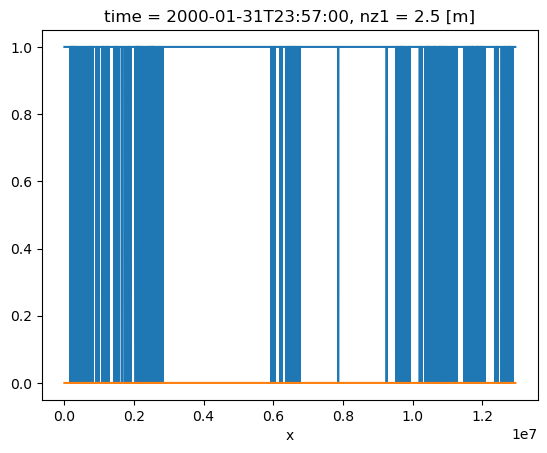

In [19]:
fig, ax = plt.subplots()
maskS.isel(nz1=-4).plot(ax=ax)
maskS.isel(nz1=0).plot(ax=ax)

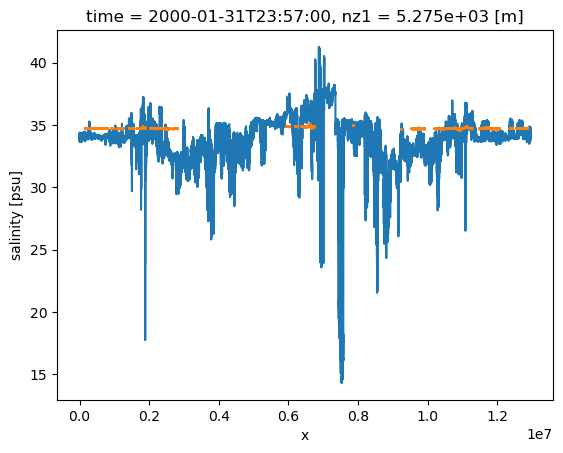

In [21]:
fig, ax = plt.subplots()
ds1.salt.where(~maskS).isel(time=0,nz1=0).plot(ax=ax)
ds1.salt.where(~maskS).isel(time=0,nz1=-4).plot(ax=ax)

In [ ]:
ystart = 2000
NXX = 48
months = range(12)

for yy in range(ystart,2011):
    
    u_path = op.join(ddir,'N%02d/outdata/fesom/unod.fesom.%4d.nc'
                     % (NXX,yy))
    v_path = op.join(ddir,'N%02d/outdata/fesom/vnod.fesom.%4d.nc'
                     % (NXX,yy))
    t_path = op.join(ddir,'N%02d/outdata/fesom/temp.fesom.%4d.nc'
                     % (NXX,yy))
    s_path = op.join(ddir,'N%02d/outdata/fesom/salt.fesom.%4d.nc'
                     % (NXX,yy))
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                     % (NXX,yy))
    unod = xr.open_dataset(u_path).rename_dims({'x':'nod2'}).unod.chunk({"time":1,"nz1":1,"nod2":100000})
    vnod = xr.open_dataset(v_path).rename_dims({'x':'nod2'}).vnod.chunk({"time":1,"nz1":1,"nod2":100000})
    temp = xr.open_dataset(t_path).rename_dims({'x':'nod2'}).temp.chunk({"time":1,"nz1":1,"nod2":100000})
    salt = xr.open_dataset(s_path).rename_dims({'x':'nod2'}).salt.chunk({"time":1,"nz1":1,"nod2":100000})
    mld  = xr.open_dataset(h_path).rename_dims({'x':'nod2'}).MLD3.chunk({"time":1,"nod2":100000})
#     mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
#                               vname="MLD3", do_info=False,
#                               year=2000, mon=1
#                              ).chunk({'nod2':100000})

    ke = .5*(unod**2 + vnod**2)
            # ke.coords["nz1"] = ("nz1",dz.nz1.data)
        

    
    for mm in months:
        
#         for i in range(len(ds1.nz1)):
#             if i == 0:
#                 temp = tpv.load_data_fesom2(mesh, t_path, do_filename=True,
#                                           vname="temp", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                 salt = tpv.load_data_fesom2(mesh, s_path, do_filename=True,
#                                           vname="salt", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                 unod = tpv.load_data_fesom2(mesh, u_path, do_filename=True,
#                                           vname="unod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                 vnod = tpv.load_data_fesom2(mesh, v_path, do_filename=True,
#                                           vname="vnod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#             else:
#                 temp = xr.concat([temp,
#                                   tpv.load_data_fesom2(mesh, t_path, do_filename=True,
#                                           vname="temp", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
#                 salt = xr.concat([salt,
#                                   tpv.load_data_fesom2(mesh, s_path, do_filename=True,
#                                           vname="salt", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
#                 unod = xr.concat([unod,
#                                   tpv.load_data_fesom2(mesh, u_path, do_filename=True,
#                                           vname="unod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
#                 vnod = xr.concat([vnod,
#                                   tpv.load_data_fesom2(mesh, v_path, do_filename=True,
#                                           vname="vnod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
                
#         temp.coords["nz1"] = ("nz1",dz.nz1.data)
#         salt.coords["nz1"] = ("nz1",dz.nz1.data)
#         ke = .5*(unod**2 + vnod**2)
#             # ke.coords["nz1"] = ("nz1",dz.nz1.data)
        maskS = xr.DataArray(salt.where(salt>0.).isel(time=mm).to_masked_array().mask,
                             dims=salt.isel(time=mm).dims, 
                             coords=salt.isel(time=mm).coords
                            ).chunk(salt.isel(time=mm).chunks)
        Vol = (diag.nod_area * dz).where(~maskS)
        
        if mm == 0:
            tave = ((temp.isel(time=mm).where(~maskS) * Vol).sum(skipna=True)
                    / Vol.sum(skipna=True)
                   )
            save = ((salt.isel(time=mm).where(~maskS) * Vol).sum(skipna=True)
                    / Vol.sum(skipna=True)
                   )
            kave = ((ke.isel(time=mm).where(~maskS) * Vol
                    ).where(ke.nz1<np.abs(mld.isel(time=mm))).sum(skipna=True)
                    / Vol.where(ke.nz1<np.abs(mld.isel(time=mm))).sum(skipna=True)
                   )
        else:
            tave = xr.concat([tave, 
                              ((temp.isel(time=mm).where(~maskS) * Vol).sum(skipna=True)
                            / Vol.sum(skipna=True)
                           )], "time")
            save = xr.concat([save, 
                              ((salt.isel(time=mm).where(~maskS) * Vol).sum(skipna=True)
                            / Vol.sum(skipna=True)
                           )], "time")
            kave = xr.concat([kave, 
                              ((ke.isel(time=mm).where(~maskS) * Vol
                               ).where(ke.nz1<np.abs(mld.isel(time=mm))).sum(skipna=True)
                               / Vol.sum(skipna=True).where(ke.nz1<np.abs(mld.isel(time=mm)))
                              )], "time")
    
    dsave = tave.to_dataset(name="temp")
    dsave["salt"] = save
    dsave.coords["time"] = ("time",np.arange(str(yy), str(yy+1), dtype='datetime64[M]'))
    if yy == 0:
        fig, ax = plt.subplots()
        ax2 = ax.twinx()
        dsave.temp.plot(ax=ax)
        dsave.salt.plot(ax=ax2)
        plt.show()
    print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/T-S_%4d.zarr" 
                                                  % (yy)),
                                          mode="w")
    dsave.close()
    
    dsave = kave.to_dataset(name="KE")
    dsave.coords["time"] = ("time",np.arange(str(yy), str(yy+1), dtype='datetime64[M]'))
    print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/KE-mld_%4d.zarr" 
                                                  % (yy)),
                                          mode="w")
    dsave.close()
    print(yy)

<xarray.Dataset> Size: 288B
Dimensions:  (time: 12)
Coordinates:
  * time     (time) datetime64[s] 96B 2000-01-01 2000-02-01 ... 2000-12-01
Data variables:
    temp     (time) float64 96B dask.array<chunksize=(1,), meta=np.ndarray>
    salt     (time) float64 96B dask.array<chunksize=(1,), meta=np.ndarray>
